In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import sys
sys.path.append("..")
#from dpa.dpa_fit import DPA
import dpa.dpa_fit as fit
import importlib

In [2]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# First, transpose to (time, lat, lon) if needed
def data_to_torch(ds):
    temp_data = ds['Temperature']
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

def predictors_to_torch(ds):
    temp_data = ds['Predictors']
    data = temp_data.transpose('time', 'predictor_mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [4]:
# load my temperature data
# Load your NetCDF file
ds_train = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_le.nc")
ds_test = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_eth_test.nc")
ds_train


<xarray.Dataset> Size: 5GB
Dimensions:         (lat: 32, lon: 32, time: 301200, predictor_mode: 1001)
Coordinates:
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * time            (time) object 2MB 1850-01-01 00:00:00 ... 2100-12-01 00:0...
  * predictor_mode  (predictor_mode) int64 8kB 0 1 2 3 4 ... 997 998 999 1000
Data variables:
    Temperature     (lat, lon, time) float64 2GB ...
    Predictors      (predictor_mode, time) float64 2GB ...

In [5]:
ds_test

<xarray.Dataset> Size: 586MB
Dimensions:         (lat: 32, lon: 32, time: 36144, predictor_mode: 1001)
Coordinates:
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * time            (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00...
  * predictor_mode  (predictor_mode) int64 8kB 0 1 2 3 4 ... 997 998 999 1000
Data variables:
    Temperature     (lat, lon, time) float64 296MB ...
    Predictors      (predictor_mode, time) float64 289MB ...

In [6]:
x_tr = data_to_torch(ds_train)
x_te = data_to_torch(ds_test)

slp_tr = predictors_to_torch(ds_train)
slp_te = predictors_to_torch(ds_test)

torch.Size([301200, 1024])
torch.Size([36144, 1024])
torch.Size([301200, 1001])
torch.Size([36144, 1001])


In [7]:
importlib.reload(fit)
dpa = fit.DPA(data_dim=1024, latent_dims=[10,9,8,7,6,5,4,3,2,1,0], num_layer=4, hidden_dim=500, device=device, joint = True)

GPU is available, running on GPU.



In [8]:
importlib.reload(fit)
dpa.train(x_tr, slp_tr, x_te, batch_size=500, num_epochs=30, save_model_every=100, print_every_nepoch=1, save_dir="saved_models/", save_loss=False)

Start training with 603 batches each of size 500.

k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10
k_max: 10

KeyboardInterrupt: 

In [ ]:
x_re = dpa.reconstruct(x_te[0,:], gen_sample_size=1).cpu()
x_re.shape

In [14]:
slp_te.shape

torch.Size([36144, 1001])

In [ ]:
x_pred = dpa.model.predict(slp_te, double=True).cpu()

In [12]:
# Assume you still know lat_dim and lon_dim
# (You saved these when you flattened earlier!)
lat_dim, lon_dim = 32, 32
time_steps = 36144
# Step 1: (optional if needed) Move from torch to numpy
data_np_reverted = x_re.numpy()

# Step 2: Reshape to (time_steps, lat_dim, lon_dim)
data_np_reverted = data_np_reverted.reshape(time_steps, lat_dim, lon_dim)

# Step 3: Transpose to (lat_dim, lon_dim, time_steps)
data_np_reverted = data_np_reverted.transpose(1, 2, 0)  # Now (lat, lon, time)

print(data_np_reverted.shape) 

(32, 32, 36144)


In [21]:
# Create the DataArray
reconstructed_da = xr.DataArray(
    data_np_reverted,
    dims=("lat", "lon", "time"),
    coords={
        "lat": ds_test.lat,
        "lon": ds_test.lon,
        "time": ds_test.time
    },
    name="Temperature"  # You can name the variable
)

reconstructed_da

<xarray.DataArray 'Temperature' (lat: 32, lon: 32, time: 36144)> Size: 148MB
array([[[-2.9796371e-01,  2.3134832e-01,  9.3954444e-01, ...,
          2.2086205e+00,  1.7993803e+00,  2.5778930e+00],
        [-1.2366258e-01,  2.7258059e-01,  6.0542625e-01, ...,
          2.3825934e+00,  1.5460601e+00,  2.9645648e+00],
        [-2.9793161e-01,  1.7594829e-01,  6.9704992e-01, ...,
          2.5138679e+00,  1.9327257e+00,  3.3636615e+00],
        ...,
        [ 1.9111743e+00,  6.8237692e-02,  1.5439664e+00, ...,
          1.1379571e+00,  2.9865987e+00,  3.2573462e+00],
        [ 1.7360735e+00, -7.7470100e-01,  1.1328558e+00, ...,
          1.6573213e+00,  3.4861479e+00,  3.1835520e+00],
        [ 1.8413501e+00, -3.3057466e-01,  1.1513271e+00, ...,
          1.5932688e+00,  3.5784740e+00,  3.7531297e+00]],

       [[-6.5681338e-04,  1.5239987e-01,  8.0314523e-01, ...,
          2.3681312e+00,  1.4508010e+00,  1.8810844e+00],
        [ 2.6455542e-01,  3.4988084e-01,  7.3072249e-01, ...,
          2.7362146e+00,  1.9028456e+00,  2.7859144e+00],
        [-1.3427211e-01,  7.6009661e-02,  5.4402125e-01, ...,
          2.4989204e+00,  2.0825722e+00,  2.6841505e+00],
...
          4.7883372e+00,  2.9399242e+00,  4.7928295e+00],
        [ 6.1106014e+00,  5.5183377e+00, -2.3380127e+00, ...,
          5.0420365e+00,  3.2298422e+00,  5.3353548e+00],
        [ 6.4329052e+00,  5.4004421e+00, -2.5182822e+00, ...,
          4.7914743e+00,  3.5946114e+00,  5.3771558e+00]],

       [[-1.2909266e+00,  9.2631221e-01,  2.3872858e-01, ...,
         -1.7440796e+00, -5.5848241e-01,  8.8377833e-01],
        [-1.0652452e+00,  3.9219415e-01,  3.1097227e-01, ...,
         -1.8725858e+00, -1.8853765e+00,  1.5011338e+00],
        [-8.2807392e-01,  7.3648071e-01,  7.7208400e-01, ...,
         -1.7190380e+00, -1.5042104e+00,  1.8766499e+00],
        ...,
        [ 6.0164208e+00,  5.8019452e+00, -2.7019629e+00, ...,
          5.1066604e+00,  3.3067508e+00,  4.7165818e+00],
        [ 6.1231022e+00,  6.2131476e+00, -2.8273778e+00, ...,
          4.6846542e+00,  4.2560363e+00,  5.1331472e+00],
        [ 5.9429913e+00,  5.7900553e+00, -2.5433300e+00, ...,
          4.6613779e+00,  3.4371419e+00,  5.5002828e+00]]],
      shape=(32, 32, 36144), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00:00:00

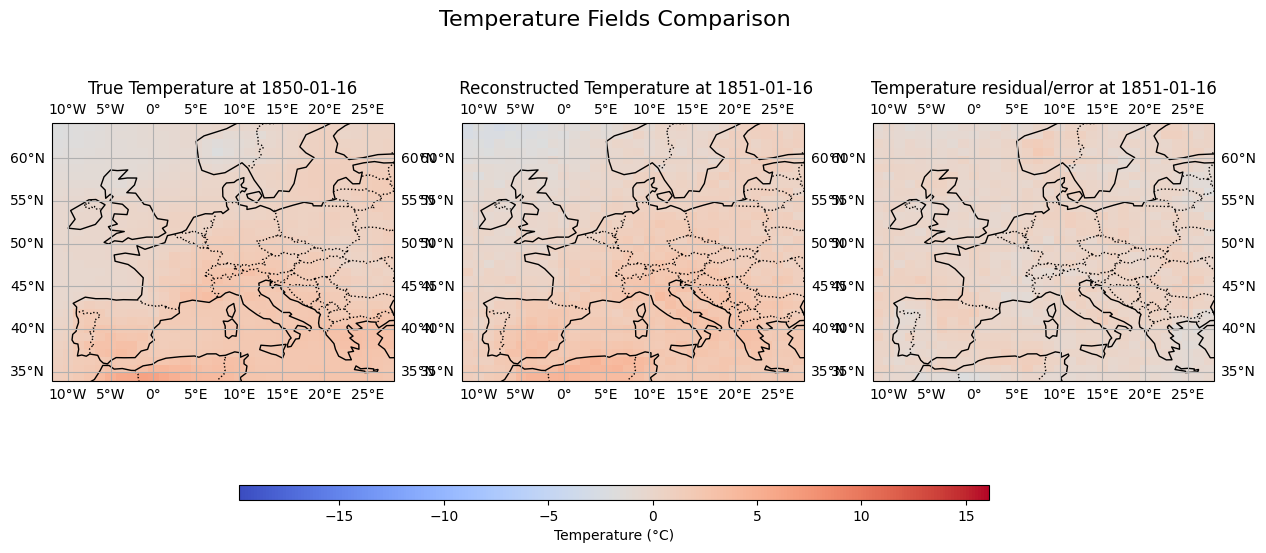

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[ 0.02012706,  0.51995242,  0.36368382, ...,  0.64705133,
         0.56891847,  0.41172445],
       [-0.41864586, -0.44340324,  0.24845767, ...,  0.88952732,
         0.48092794,  0.64109445],
       [-0.18926752,  0.2972821 ,  0.72947037, ...,  0.98633838,
         0.65580428,  0.14359713],
       ...,
       [-0.00955749,  0.19443536,  0.68611813, ..., -0.5264554 ,
        -0.21508348, -0.41334581],
       [ 0.69813633,  0.38584328,  0.6501646 , ..., -0.60575438,
         0.22800958, -0.29517347],
       [ 0.9238925 ,  0.17176306,  0.69945812, ..., -0.09191573,
         0.05644792, -0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [48]:
# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Example: Load data (you should already have your `reconstructed_da`)
# reconstructed_da = xr.open_dataset('your_file.nc')['Temperature']

# Prepare figure with 2 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()


# Set common color limits across both plots
vmin = reconstructed_da.min().item()
vmax = reconstructed_da.max().item()

# Plot on first panel
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important! No individual colorbars
)
axs[0].set_title(f"True Temperature at {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

#####################################################################
# Plot on second panel
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[1].set_title(f" Reconstructed Temperature at {str(time2.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

#####################################################################
# Plot on third panel
p3 = (reconstruction_to_plot - test_truth_to_plot).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[2].set_title(f"Temperature residual/error at {str(time2.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# ===========================
# Here's the important fix:
# Create a new axes for the colorbar
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.03])  
# [left, bottom, width, height] in figure coordinates (0 to 1)

cbar = fig.colorbar(p2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature (°C)')
# ===========================

# Add an overall figure title
fig.suptitle('Temperature Fields Comparison', fontsize=16)

#plt.tight_layout()
plt.show()

test_truth_to_plot - reconstruction_to_plot

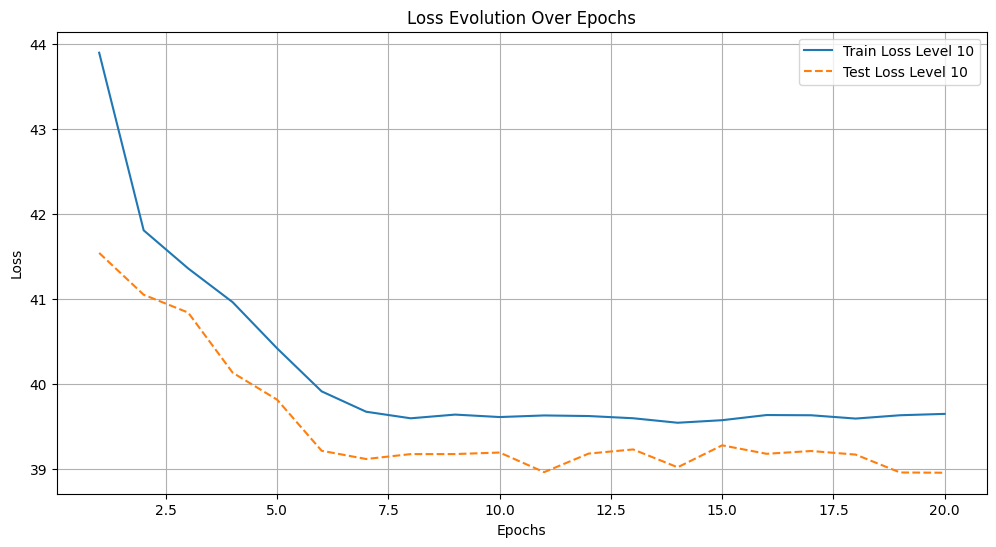

In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    """
    Parse the .log file to extract training and testing losses.

    Args:
        log_file_path (str): Path to the .log file.

    Returns:
        dict: A dictionary containing train and test losses over epochs.
    """
    train_losses = []
    test_losses = []
    with open(log_file_path, 'r') as file:
        for line in file:
            # Match train loss lines
            train_match = re.match(r"\[Epoch \d+\] (.+)", line)
            if train_match:
                train_losses.append([float(x.strip()) for x in train_match.group(1).split(",")])

            # Match test loss lines
            test_match = re.match(r"\(test\)\s+(.+)", line)
            if test_match:
                test_losses.append([float(x.strip()) for x in test_match.group(1).split(",")])

    return {
        "train": np.array(train_losses),
        "test": np.array(test_losses),
    }

def plot_loss_evolution(loss_data, k_levels=None, save_path=None):
    """
    Plot the loss evolution over epochs for selected `k` levels during training and testing.

    Args:
        loss_data (dict): A dictionary containing train and test losses over epochs.
        k_levels (list, optional): List of `k` levels to plot. Defaults to all available levels.
        save_path (str, optional): Path to save the plot. If None, the plot is displayed.
    """
    train_losses = loss_data['train']
    test_losses = loss_data['test']

    if k_levels is None:
        k_levels = range(train_losses.shape[1])  # Default to all levels

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))
    for k in k_levels:
        if k < train_losses.shape[1]:  # Ensure k is valid
            plt.plot(epochs, train_losses[:, k], label=f"Train Loss Level {k}")
            if len(test_losses) > 0:
                plt.plot(epochs, test_losses[:, k], '--', label=f"Test Loss Level {k}")
        else:
            print(f"Warning: k level {k} is out of bounds and will be ignored.")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Evolution Over Epochs")
    plt.legend()
    plt.grid()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()

# Example usage
log_file_path = "log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)

# Specify the `k` levels you want to plot, or set to `None` to plot all levels
k_levels_to_plot = [10]  # Example: Plot only levels 0 and 2
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

In [ ]:
total_residual = reconstructed_da - ds_test
total_residual

/tmp/ipykernel_3350826/2335559975.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbars


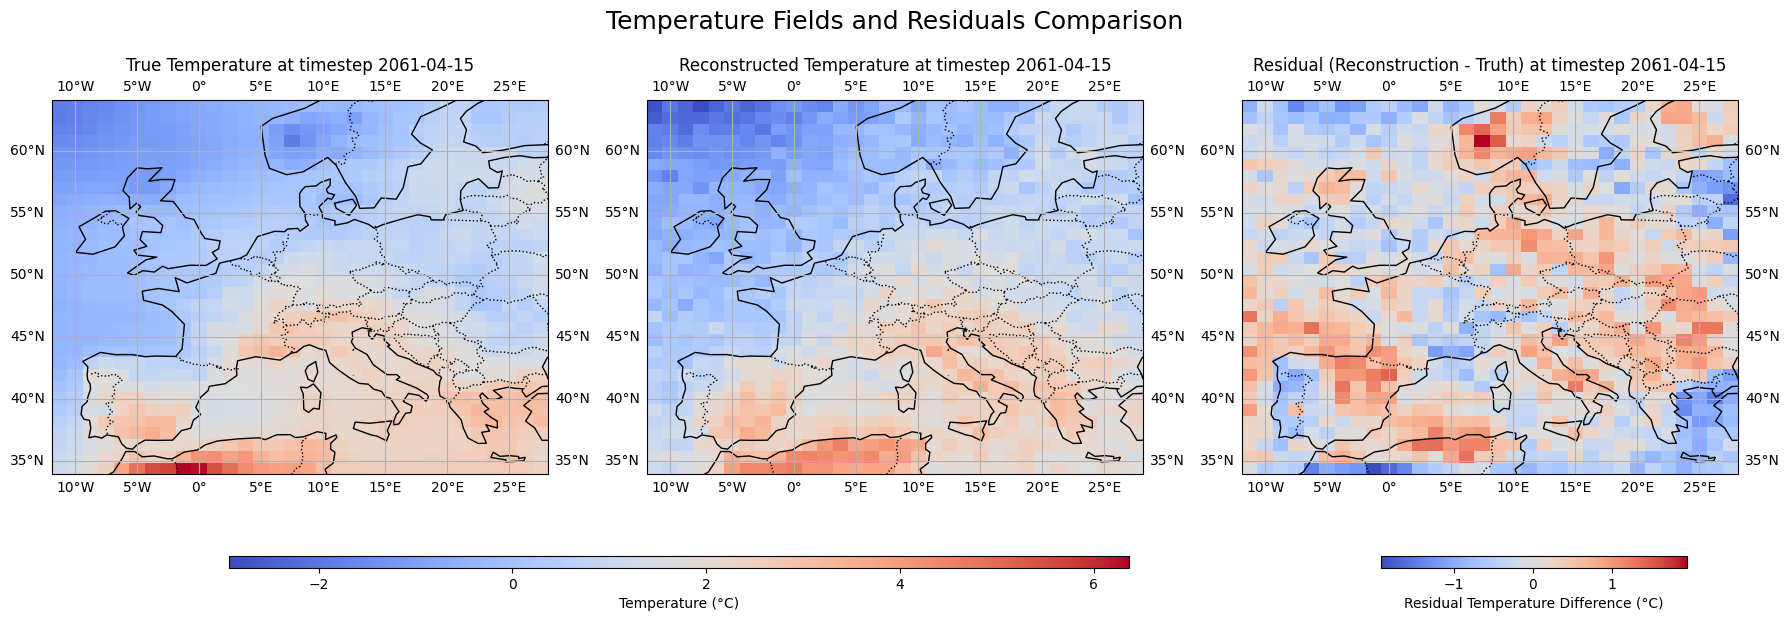

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[-0.02012706, -0.51995242, -0.36368382, ..., -0.64705133,
        -0.56891847, -0.41172445],
       [ 0.41864586,  0.44340324, -0.24845767, ..., -0.88952732,
        -0.48092794, -0.64109445],
       [ 0.18926752, -0.2972821 , -0.72947037, ..., -0.98633838,
        -0.65580428, -0.14359713],
       ...,
       [ 0.00955749, -0.19443536, -0.68611813, ...,  0.5264554 ,
         0.21508348,  0.41334581],
       [-0.69813633, -0.38584328, -0.6501646 , ...,  0.60575438,
        -0.22800958,  0.29517347],
       [-0.9238925 , -0.17176306, -0.69945812, ...,  0.09191573,
        -0.05644792,  0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)
time1 = reconstruction_to_plot.time

# Prepare figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()

# Set shared color limits for the first two panels
vmin_shared = min(test_truth_to_plot.min().item(), reconstruction_to_plot.min().item())
vmax_shared = max(test_truth_to_plot.max().item(), reconstruction_to_plot.max().item())

# Set separate color limits for the residual
residual = reconstruction_to_plot - test_truth_to_plot
vmin_residual = residual.min().item()
vmax_residual = residual.max().item()

# --- Plot first panel: True Temperature ---
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_shared,
    vmax=vmax_shared,
    add_colorbar=False
)
axs[0].set_title(f"True Temperature at timestep {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

# --- Plot second panel: Reconstructed Temperature ---
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_shared,
    vmax=vmax_shared,
    add_colorbar=False
)
axs[1].set_title(f"Reconstructed Temperature at timestep {str(time1.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

# --- Plot third panel: Residual/Error ---
p3 = residual.plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_residual,
    vmax=vmax_residual,
    add_colorbar=False
)
axs[2].set_title(f"Residual (Reconstruction - Truth) at timestep {str(time1.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# =======================
# Create shared colorbar for the first two panels
cbar_ax_shared = fig.add_axes([0.13, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
cbar_shared = fig.colorbar(p1, cax=cbar_ax_shared, orientation='horizontal')
cbar_shared.set_label('Temperature (°C)')

# Create separate colorbar for residual
cbar_ax_residual = fig.add_axes([0.77, 0.05, 0.17, 0.02])  # [left, bottom, width, height]
cbar_residual = fig.colorbar(p3, cax=cbar_ax_residual, orientation='horizontal')
cbar_residual.set_label('Residual Temperature Difference (°C)')
# =======================

# Add overall figure title
fig.suptitle('Temperature Fields and Residuals Comparison', fontsize=18)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbars
plt.show()

# (Optional) if you want to immediately see the numerical residual
residual
